## Stock Market Data Analysis



In [487]:
'''
• Load the provided dataset using Pandas.
• Use Matplotlib & Seaborn for visualization.
• Apply Scikit-Learn for predictive modeling.
• Submit your Jupyter Notebook (.ipynb) or Python script (.py) on Moodle.
'''
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

### 1. Data Loading and Cleaning

In [488]:
# [1]. Load the dataset into a Pandas DataFrame. Set the Date column to datetime format.
df = pd.read_csv('stock.csv', parse_dates=True, index_col="Date")
df

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2010-06-29,19.000000,25.000000,17.540001,23.889999,18766300,23.889999
2010-06-30,25.790001,30.420000,23.299999,23.830000,17187100,23.830000
2010-07-01,25.000000,25.920000,20.270000,21.959999,8218800,21.959999
2010-07-02,23.000000,23.100000,18.709999,19.200001,5139800,19.200001
2010-07-06,20.000000,20.000000,15.830000,16.110001,6866900,16.110001
...,...,...,...,...,...,...
2017-03-13,244.820007,246.850006,242.779999,246.169998,3010700,246.169998
2017-03-14,246.110001,258.119995,246.020004,258.000000,7575500,258.000000
2017-03-15,257.000000,261.000000,254.270004,255.729996,4816600,255.729996


In [489]:
# [2]. Display the first 5 rows and check for missing values.
print("First 5 rows:")
print(df.head())
print('\n Missing values:')
print(df.isnull().sum(), '\n')

First 5 rows:
                 Open   High        Low      Close    Volume  Adj Close
Date                                                                   
2010-06-29  19.000000  25.00  17.540001  23.889999  18766300  23.889999
2010-06-30  25.790001  30.42  23.299999  23.830000  17187100  23.830000
2010-07-01  25.000000  25.92  20.270000  21.959999   8218800  21.959999
2010-07-02  23.000000  23.10  18.709999  19.200001   5139800  19.200001
2010-07-06  20.000000  20.00  15.830000  16.110001   6866900  16.110001

 Missing values:
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64 



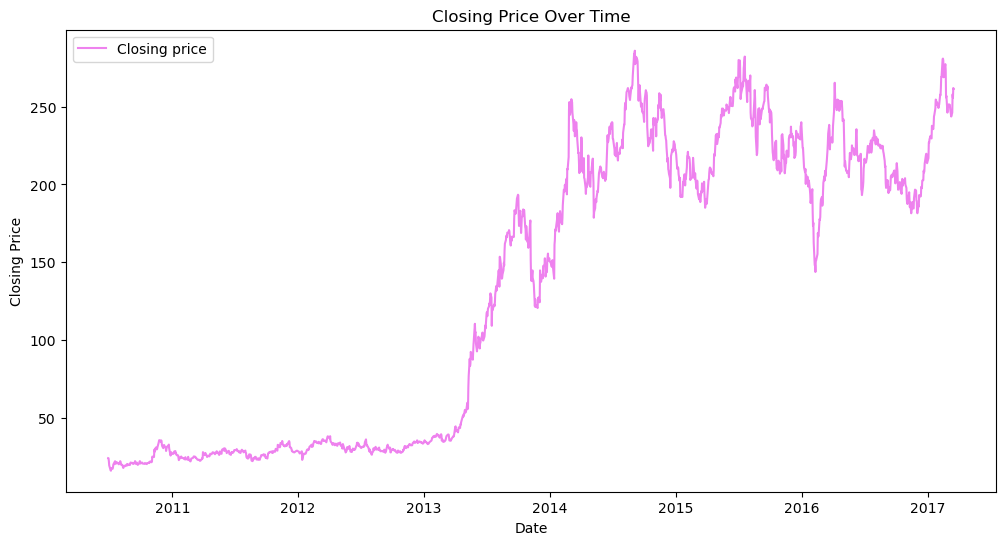

In [490]:
# [3]. Plot the closing price over time using a line plot.
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Close', label='Closing price', color='violet')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Closing Price Over Time')
plt.show()

### 2. Line Plots with Moving Averages

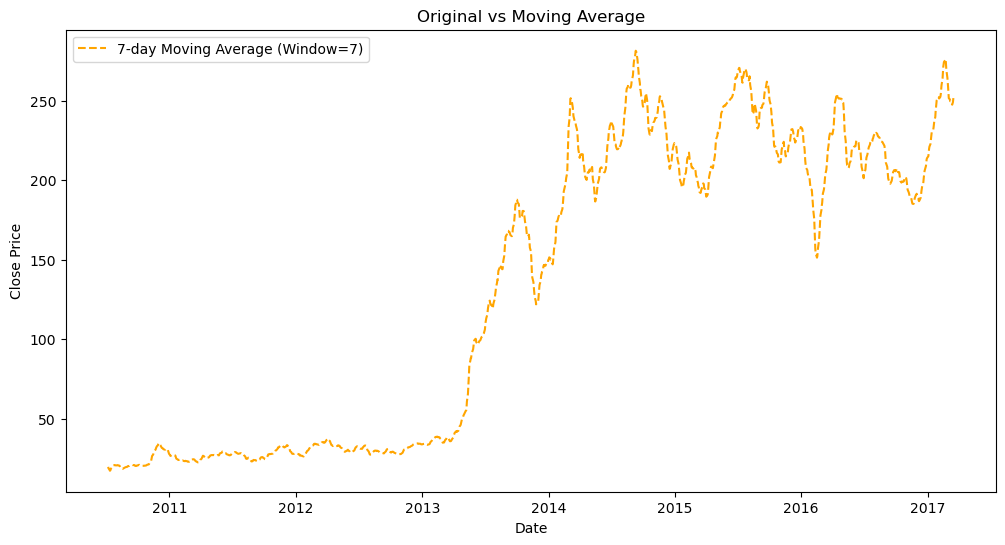

In [491]:
# [1]. Compute a 7-day moving average and a 30-day moving average for the closing price.
window_size_7 = 7
df['7_day_Moving_Avg'] = df['Close'].rolling(window=window_size_7).mean()

plt.figure(figsize=(12, 6))

# plt.plot(df['Close'], label='Original Close Price', color='blue')
plt.plot(df['7_day_Moving_Avg'], label=f'7-day Moving Average (Window={window_size_7})', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()

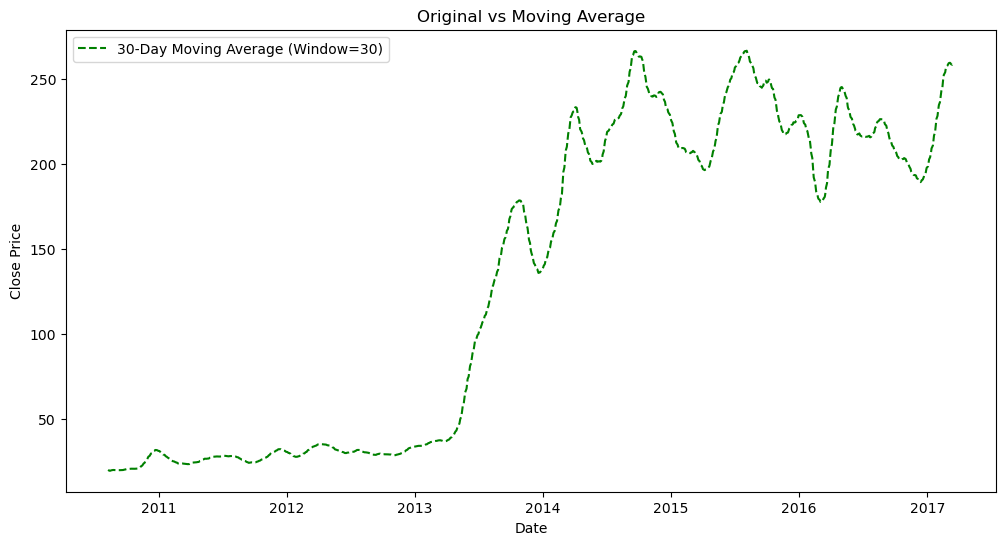

In [492]:
window_size_30 = 30
df['30_day_Moving_Avg'] = df['Close'].rolling(window=window_size_30).mean()

plt.figure(figsize=(12, 6))

# plt.plot(df['Close'], label='Original Close Price', color='blue')
plt.plot(df['30_day_Moving_Avg'], label=f'30-Day Moving Average (Window={window_size_30})', linestyle='--', color='green')

plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()

# df_resampled = df.resample('ME').mean(numeric_only=True)

# plt.figure(figsize=(12, 6))
# sns.lineplot(data=df_resampled, x=df_resampled. index, y='Close', label='Month Wise Average High Price', color='blue')

# # Adding labels and title
# plt.xlabel('Date (Monthly)')
# plt.ylabel('High')
# plt.title('Monthly Resampling Highest Price Over Time')
# plt.show()

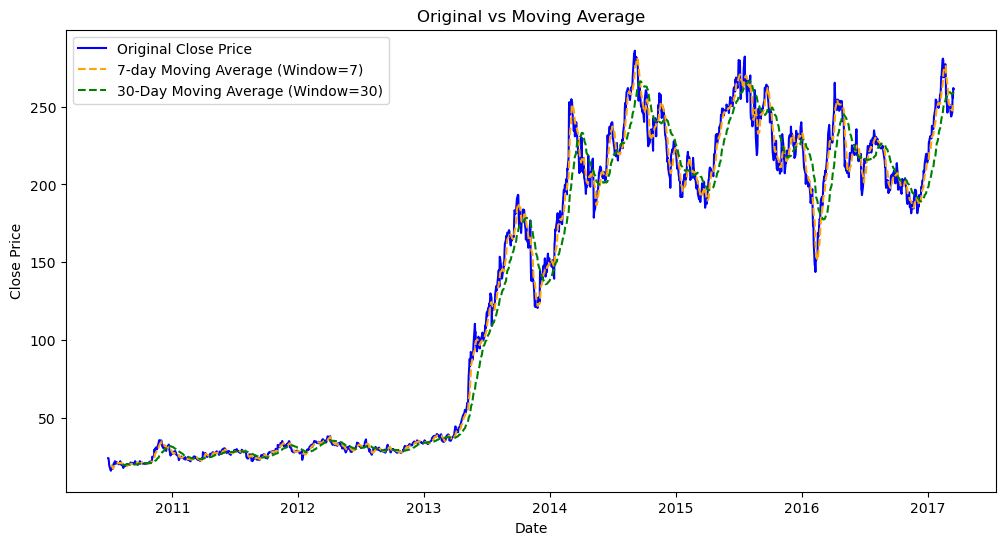

In [493]:
# [2]. Plot the original closing price along with the moving averages on the same graph.
plt.figure(figsize=(12, 6))

plt.plot(df['Close'], label='Original Close Price', color='blue')
plt.plot(df['7_day_Moving_Avg'], label=f'7-day Moving Average (Window={window_size_7})', linestyle='--', color='orange')
plt.plot(df['30_day_Moving_Avg'], label=f'30-Day Moving Average (Window={window_size_30})', linestyle='--', color='green')

plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()

### 3. Analyze the relationship between stock trading volume and price movements


In [495]:
'''
[1]. Create a new column called “Price_Category” in the data frame to divide each day’s stock price into 3 groups based on the following rule: (Use df.quantile() to compute the percentile)
i. If the closing price is below the 33rd percentile of the Close column, categorize it as ‘Low’.
ii. If the closing price is between the 33rd and 66th percentile of the Close column, categorize it as ‘Medium’.
iii. If the closing price is above the 66th percentile of the Close column, categorize it as ‘High’.
'''
low_threshold = df['Close'].quantile(0.33)
high_threshold = df['Close'].quantile(0.66)

df['Price_Category'] = pd.cut(
    df['Close'],
    bins=[-float('inf'), low_threshold, high_threshold, float('inf')],
    labels=['Low', 'Medium', 'High']
)


df[['Close', 'Price_Category']]

,Close,Price_Category
Date,,
2010-06-29,23.889999,Low
2010-06-30,23.830000,Low
2010-07-01,21.959999,Low
2010-07-02,19.200001,Low
2010-07-06,16.110001,Low
...,...,...
2017-03-13,246.169998,High
2017-03-14,258.000000,High
2017-03-15,255.729996,High


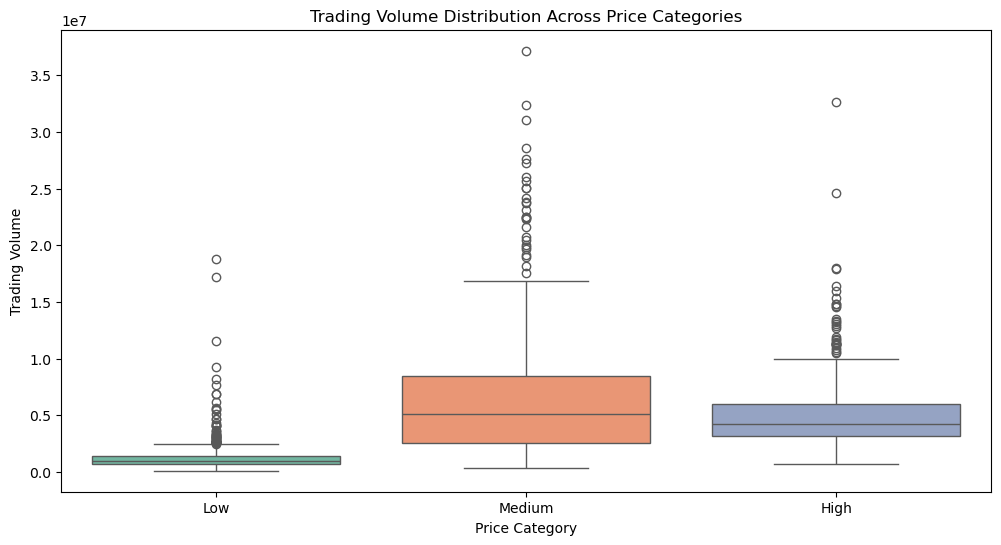

In [496]:
# [2]. Create a boxplot to compare Trading Volume distributions across different stock price categories.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Price_Category', y='Volume', hue="Price_Category", palette='Set2')

plt.xlabel('Price Category')
plt.ylabel('Trading Volume')
plt.title('Trading Volume Distribution Across Price Categories')

plt.show()

### 4. Stock Price Prediction Using Machine Learning


In [497]:
df

,Open,High,Low,Close,Volume,Adj Close,7_day_Moving_Avg,30_day_Moving_Avg,Price_Category
Date,,,,,,,,,
2010-06-29,19.000000,25.000000,17.540001,23.889999,18766300,23.889999,NaN,NaN,Low
2010-06-30,25.790001,30.420000,23.299999,23.830000,17187100,23.830000,NaN,NaN,Low
2010-07-01,25.000000,25.920000,20.270000,21.959999,8218800,21.959999,NaN,NaN,Low
2010-07-02,23.000000,23.100000,18.709999,19.200001,5139800,19.200001,NaN,NaN,Low
2010-07-06,20.000000,20.000000,15.830000,16.110001,6866900,16.110001,NaN,NaN,Low
...,...,...,...,...,...,...,...,...,...
2017-03-13,244.820007,246.850006,242.779999,246.169998,3010700,246.169998,247.571428,258.219003,High
2017-03-14,246.110001,258.119995,246.020004,258.000000,7575500,258.000000,248.489999,258.464670,High
2017-03-15,257.000000,261.000000,254.270004,255.729996,4816600,255.729996,249.135712,258.591337,High


In [498]:
# [1]. Predict next day closing price using the Ridge Regression model in scikit-learn (Use 7-day moving average and 30-day moving average as features).
df['Next_Day_Close'] = df['Close'].shift(-1)

# Drop rows with NaN values
df.dropna(inplace=True)

X = df[['7_day_Moving_Avg', '30_day_Moving_Avg']]
y = df['Next_Day_Close']


In [500]:
# [2]. Split the data into training (80%) and testing (20%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [501]:
# [3]. Train a Ridge Regression model to predict stock prices.
model = Ridge(alpha=1.0) # Instantiate
model.fit(X_train, y_train) # Fit model to data
y_pred = model.predict(X_test) # Predict on new data

In [502]:
# [4]. Evaluate the model using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Mean Absolute Error (MAE): 4.974745725375246
Root Mean Squared Error (RMSE): 7.522152246163086


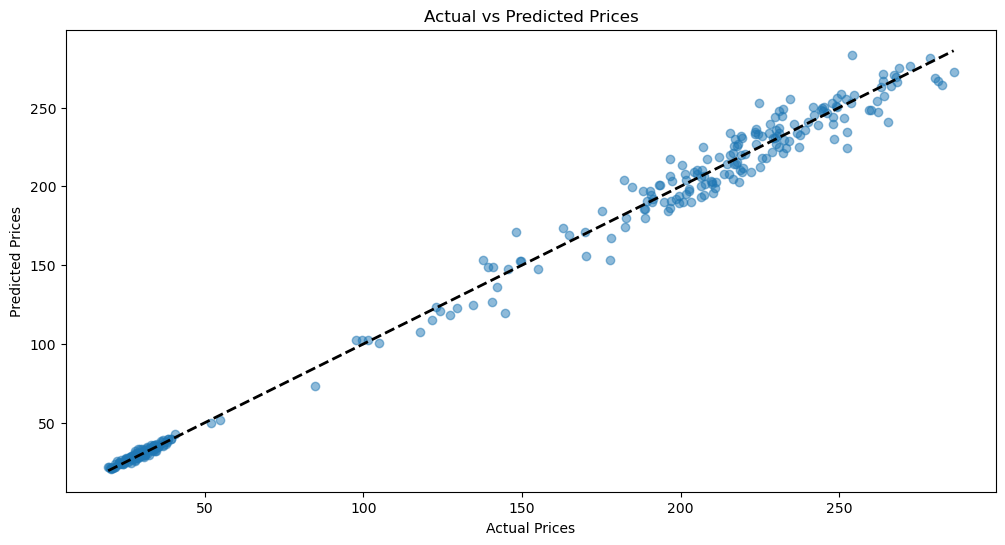

In [503]:
# [5]. Plot actual vs. predicted prices.
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)